Created in collaboration with AI tools (specifically MS CoPilot)

# Objective



 **Predictive Maintenance**:

 Deploy AI algorithms to monitor the performance and condition of material-handling equipment in real-time. By analyzing data from embedded sensors, AI can detect patterns and forecast equipment failures, enabling proactive maintenance that minimizes downtime and extends equipment lifespan.

 This project will allow application of AI/ML skills while gaining practical, hands-on experience in intralogistics.

# Steps in the Project

Predictive Maintenance is transformative for intralogistics, offering efficiency, cost savings, and reliability. Here are the steps to deploy an AI-driven solution:

### Step 1: **Understand the Problem Scope**

- Identify key equipment for monitoring (e.g., conveyors, forklifts, automated guided vehicles).
- Determine critical performance metrics and failure indicators (e.g., vibration, temperature, motor torque).
- Define measurable goals, like reducing downtime by X% or extending equipment lifespan by Y%.

For this project, I have identified the key equipment for monitoring to be:

Automated Guided Vehicles, specifically warehouse forklifts.

The critical performance metrics and failure indicators for this equipment are:

That's a great approach—generating data for learning gives you full control over the process, and incorporating GenAI will add a creative twist. For AGV forklifts, here are specific metrics that can provide valuable insights into their performance and condition:

1. **Operational Metrics**
- **Utilization Rate**: Tracks how much time the forklift is in use compared to idle, helping optimize fleet allocation.
- **Distance Traveled**: Monitors routes and wear on wheels or drive mechanisms.
- **Load Weight**: Records the weight carried to assess wear on lifting components.
***failure indicators**
  - **Utilization Rate**: Unusually low utilization might hint at intermittent downtime or malfunctions.
  - **Distance Traveled**: Sudden reductions in distance covered could indicate navigation issues or wear on drive mechanisms.

2. **Mechanical Health Metrics**
- **Vibration Levels**: Increased vibration may indicate issues with motors, gears, or wheel alignment.
- **Temperature Readings**: Tracks overheating in motors, batteries, or hydraulic systems.
- **Battery Voltage & Charge Cycles**: Monitors battery health to prevent breakdowns and optimize charging schedules.
***failure indicators**
  - **Vibration Levels**: Spikes in vibration often signal problems with motors, wheels, or gears—clear indicators of mechanical failure.
  - **Temperature Readings**: Elevated temperatures in motors, batteries, or hydraulic systems suggest impending overheating or component wear.
  - **Battery Voltage & Charge Cycles**: Low battery voltage or excessive charge cycles might predict battery failure.

3. **Environmental Interaction Metrics**
- **Navigation Errors**: Tracks deviations from intended paths, which could indicate sensor or software malfunctions.
- **Obstacle Detection Alerts**: Monitors how often the AGV detects objects in its path, identifying potential misalignment or sensor issues.
***failure indicators**
  - **Navigation Errors**: Increased path deviations can reflect sensor malfunctions or software issues.
  - **Obstacle Detection Alerts**: Frequent alerts may indicate misaligned sensors or structural damage, affecting the AGV’s ability to function.

4. **Maintenance Metrics**
- **Component Lifespan**: Predicts wear and tear on tires, chains, or hydraulic cylinders based on usage patterns.
- **Mean Time Between Failures (MTBF)**: Estimates intervals between equipment breakdowns for scheduling proactive maintenance.
***failure indicators**
  - **Component Lifespan**: Shortened lifespans for tires, chains, or hydraulic cylinders may signal wear-and-tear leading to failure.
  - **Mean Time Between Failures (MTBF)**: Declining MTBF values highlight recurring issues that demand immediate attention.



### Step 2: **Data Collection**
- Ensure the necessary sensors are embedded in equipment to collect real-time data.
- Aggregate historical data about equipment failures and maintenance records for model training.
- Structure the data—clean it, normalize it, and handle missing values—for optimal analysis.

We will utilize synthetic, tabular data for our data.  We may also augmetn the data later in the project depending on the performance of the model(s).


What is Time-Series Data?

Time-series data consists of observations collected over time at consistent intervals, such as every second, minute, hour, or day. Each data point is timestamped, allowing us to analyze patterns, trends, and changes over time.

Time-series analysis techniques (like ARIMA, LSTMs, or Exponential Smoothing) are often used to model this data and make predictions.

These features are the for predictive maintenance project with AGV forklifts that align with the metrics in the scope of this priject.

1. **Timestamp**: A foundation for time-series analysis, showing when data was recorded.
2. **Utilization Rate**: Insight into usage patterns—key for fleet optimization and detecting downtime.
3. **Distance Traveled**: Tracks wear on drive mechanisms and helps identify anomalies in movement efficiency.
4. **Vibration Levels**: An essential indicator of mechanical health, predicting issues like misalignment or motor problems.
5. **Temperature Readings**: Detects overheating in components like motors and batteries.
6. **Battery Voltage & Charge Cycles**: Crucial for monitoring battery health and preventing energy-related failures.
7. **Navigation Error**: Signals sensor or software malfunctions that could impair autonomous operation.
8. **Obstacle Detection Alerts**: Reflects the forklift's interaction with the environment; frequent alerts may indicate miscalibrated sensors.
9. **Component Lifespan**: Tracks wear and tear on individual parts, aiding in proactive replacements.
10. **Mean Time Between Failures (MTBF)**: Helps measure reliability over time and predict maintenance windows.



### Step 3: **Model Development**
- Use Machine Learning techniques like supervised learning to create predictive models. Algorithms like Random Forests or Gradient Boosting are great for this task.
- Split the data into training and testing sets, ensuring the model generalizes well.
- Evaluate metrics like accuracy and recall to measure the model’s ability to predict failures.

### Step 4: **Deployment and Integration**
- Integrate the model with an IoT platform that connects to equipment sensors for real-time predictions.
- Develop a dashboard for maintenance teams to visualize predictions and alerts.
- Automate notifications to prompt proactive maintenance actions.

### Step 5: **Continuous Improvement**
- Retrain the model periodically with new data to adapt to changing conditions.
- Analyze feedback from maintenance teams to refine thresholds and decision-making processes.
- Incorporate additional variables or equipment types as the system evolves.

# Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px
import plotly.graph_objects as go
from pandas.plotting import autocorrelation_plot
from sklearn.cluster import KMeans

# Data

Test data set

In [3]:
# import pandas as pd
# import numpy as np

# Set a new random seed for the test dataset
np.random.seed(123)  # Ensure this test dataset is different from the training/validation data

# Generate timestamps (e.g., one reading every 5 minutes for 3 days)
test_timestamps = pd.date_range(start="2025-04-09", end="2025-04-12", freq="5T")

# Generate synthetic data for each feature
test_utilization_rate = np.random.uniform(50, 100, len(test_timestamps))  # Percentage
test_distance_traveled = np.random.uniform(0.1, 10, len(test_timestamps))  # Miles
test_vibration_levels = np.random.uniform(0, 1, len(test_timestamps))  # in/s
test_temperature_readings = np.random.uniform(75, 150, len(test_timestamps))  # Fahrenheit
test_battery_voltage = np.random.uniform(10, 14, len(test_timestamps))  # Volts
test_charge_cycles = np.random.randint(0, 500, len(test_timestamps))  # Total cycles
test_navigation_error = np.random.randint(0, 5, len(test_timestamps))  # Error count
test_obstacle_detection_alerts = np.random.randint(0, 10, len(test_timestamps))  # Alert count
test_component_lifespan = np.random.uniform(50, 200, len(test_timestamps))  # Hours remaining
test_mtbf = np.random.uniform(100, 1000, len(test_timestamps))  # Hours

# Create a DataFrame for the test dataset
test_data = pd.DataFrame({
    "Timestamp": test_timestamps,
    "Utilization Rate (%)": test_utilization_rate,
    "Distance Traveled (mi)": test_distance_traveled,
    "Vibration Levels (in/s)": test_vibration_levels,
    "Temperature (°F)": test_temperature_readings,
    "Battery Voltage (V)": test_battery_voltage,
    "Charge Cycles": test_charge_cycles,
    "Navigation Errors": test_navigation_error,
    "Obstacle Detection Alerts": test_obstacle_detection_alerts,
    "Component Lifespan (hours)": test_component_lifespan,
    "MTBF (hours)": test_mtbf
})

# Save the test dataset to a CSV file
test_data.to_csv("synthetic_test_data.csv", index=False)

# Display the first few rows of the test dataset
test_data.head()


<ipython-input-3-8096186e6920>:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  test_timestamps = pd.date_range(start="2025-04-09", end="2025-04-12", freq="5T")


,Timestamp,Utilization Rate (%),Distance Traveled (mi),Vibration Levels (in/s),Temperature (°F),Battery Voltage (V),Charge Cycles,Navigation Errors,Obstacle Detection Alerts,Component Lifespan (hours),MTBF (hours)
0,2025-04-09 00:00:00,84.823459,6.759715,0.824565,77.281141,13.586481,258,2,1,194.932040,601.633579
1,2025-04-09 00:05:00,64.306967,6.582051,0.394075,118.060822,11.474870,144,1,9,97.688189,351.197477
2,2025-04-09 00:10:00,61.342573,1.107286,0.813475,124.647741,12.339370,241,2,7,160.723588,945.252174
3,2025-04-09 00:15:00,77.565738,8.439636,0.849249,142.112326,11.614184,265,0,1,133.138116,513.906182
4,2025-04-09 00:20:00,85.973448,6.180307,0.281660,79.632867,12.265585,485,2,1,136.835221,599.994234


Key Details

Different Seed:

Using a new seed (np.random.seed(123)) ensures the synthetic test data is statistically similar but distinct from the training data.


Shorter Timeframe:

Generated over 3 days (as opposed to 7 days for the training data) to reduce redundancy.


Saved Separately:

The test dataset is saved as synthetic_test_data.csv for easy access during final model evaluation.

In [ ]:
# np.random.seed(123)  # Set a different seed
# test_data = pd.DataFrame({
#     # Generate new synthetic features similar to your training data
#     "timestamp": pd.date_range(start="2025-04-09", periods=500, freq="5T"),
#     "vibration_levels": np.random.uniform(0, 1, 500),
#     # Add other columns here
# })


Training data set

In [4]:
# import pandas as pd
# import numpy as np

# Set the random seed for reproducibility
np.random.seed(42)

# Generate timestamps (e.g., one reading every 5 minutes for 7 days)
timestamps = pd.date_range(start="2025-04-01", end="2025-04-08", freq="5T")

# Generate synthetic data for each feature
utilization_rate = np.random.uniform(50, 100, len(timestamps))  # Percentage
distance_traveled_km = np.random.uniform(0.1, 10, len(timestamps))  # Kilometers
distance_traveled_mi = distance_traveled_km * 0.621371  # Convert km to miles
vibration_levels_mm = np.random.uniform(0, 1, len(timestamps))  # mm/s
vibration_levels_in = vibration_levels_mm * 0.0393701  # Convert mm/s to in/s
temperature_c = np.random.uniform(25, 85, len(timestamps))  # Celsius
temperature_f = (temperature_c * 9/5) + 32  # Convert °C to °F
battery_voltage = np.random.uniform(10, 14, len(timestamps))  # Volts
charge_cycles = np.random.randint(0, 500, len(timestamps))  # Total cycles
navigation_error = np.random.randint(0, 5, len(timestamps))  # Error count
obstacle_detection_alerts = np.random.randint(0, 10, len(timestamps))  # Alert count
component_lifespan = np.random.uniform(50, 200, len(timestamps))  # Hours remaining
mtbf = np.random.uniform(100, 1000, len(timestamps))  # Hours

# Create a DataFrame
data = pd.DataFrame({
    "Timestamp": timestamps,
    "Utilization Rate (%)": utilization_rate,
    "Distance Traveled (mi)": distance_traveled_mi,
    "Vibration Levels (in/s)": vibration_levels_in,
    "Temperature (°F)": temperature_f,
    "Battery Voltage (V)": battery_voltage,
    "Charge Cycles": charge_cycles,
    "Navigation Errors": navigation_error,
    "Obstacle Detection Alerts": obstacle_detection_alerts,
    "Component Lifespan (hours)": component_lifespan,
    "MTBF (hours)": mtbf
})

# Save the data to a CSV file
data.to_csv("synthetic_agv_data_us_units.csv", index=False)

# Display the first few rows of the dataset
data.head()


<ipython-input-4-76c2cf856a9b>:8: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  timestamps = pd.date_range(start="2025-04-01", end="2025-04-08", freq="5T")


,Timestamp,Utilization Rate (%),Distance Traveled (mi),Vibration Levels (in/s),Temperature (°F),Battery Voltage (V),Charge Cycles,Navigation Errors,Obstacle Detection Alerts,Component Lifespan (hours),MTBF (hours)
0,2025-04-01 00:00:00,68.727006,5.597528,0.006150,179.630156,11.796494,205,4,7,75.967254,511.151887
1,2025-04-01 00:05:00,97.535715,0.196385,0.038914,134.854409,12.282658,389,4,0,88.695626,220.008217
2,2025-04-01 00:10:00,86.599697,4.145488,0.038476,119.572573,11.742357,461,3,3,163.510862,571.013645
3,2025-04-01 00:15:00,79.932924,5.988528,0.031253,168.605938,11.659387,80,4,2,166.285284,761.159836
4,2025-04-01 00:20:00,57.800932,3.508053,0.025962,130.242133,12.930894,273,3,4,110.734579,598.008497


In [5]:
# Save the DataFrame to a variable named df
df = data

# Confirm that df now holds the same data
df.head()


,Timestamp,Utilization Rate (%),Distance Traveled (mi),Vibration Levels (in/s),Temperature (°F),Battery Voltage (V),Charge Cycles,Navigation Errors,Obstacle Detection Alerts,Component Lifespan (hours),MTBF (hours)
0,2025-04-01 00:00:00,68.727006,5.597528,0.006150,179.630156,11.796494,205,4,7,75.967254,511.151887
1,2025-04-01 00:05:00,97.535715,0.196385,0.038914,134.854409,12.282658,389,4,0,88.695626,220.008217
2,2025-04-01 00:10:00,86.599697,4.145488,0.038476,119.572573,11.742357,461,3,3,163.510862,571.013645
3,2025-04-01 00:15:00,79.932924,5.988528,0.031253,168.605938,11.659387,80,4,2,166.285284,761.159836
4,2025-04-01 00:20:00,57.800932,3.508053,0.025962,130.242133,12.930894,273,3,4,110.734579,598.008497


In [6]:
# view the shape or size of the dataset
df.shape

(2017, 11)

The script generates one observation every 5 minutes from April 1, 2025 to April 8, 2025.

That’s a total of 7 days worth of data:

7 days × 24 hours × 60 minutes = 10,080 minutes

Observations are recorded every 5 minutes:

10,080 minutes / 5 minutes = 2,016 rows

In [7]:
# view the data types of the features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2017 entries, 0 to 2016
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Timestamp                   2017 non-null   datetime64[ns]
 1   Utilization Rate (%)        2017 non-null   float64       
 2   Distance Traveled (mi)      2017 non-null   float64       
 3   Vibration Levels (in/s)     2017 non-null   float64       
 4   Temperature (°F)            2017 non-null   float64       
 5   Battery Voltage (V)         2017 non-null   float64       
 6   Charge Cycles               2017 non-null   int64         
 7   Navigation Errors           2017 non-null   int64         
 8   Obstacle Detection Alerts   2017 non-null   int64         
 9   Component Lifespan (hours)  2017 non-null   float64       
 10  MTBF (hours)                2017 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(3)
memory usage:

In [8]:
# standardize the column names

# Function to clean column names
def clean_column_names(df):
    df.columns = (df.columns
                  .str.lower()  # Convert to lowercase
                  .str.replace(r'[^\w\s]', '', regex=True)  # Remove punctuation
                  .str.replace(r'\s+', '_', regex=True)  # Replace spaces with underscores
                  .str.rstrip('_'))  # Remove trailing underscores
    return df

# Apply the function
df = clean_column_names(df)

# Print cleaned column names
df.columns


Index(['timestamp', 'utilization_rate', 'distance_traveled_mi',
       'vibration_levels_ins', 'temperature_f', 'battery_voltage_v',
       'charge_cycles', 'navigation_errors', 'obstacle_detection_alerts',
       'component_lifespan_hours', 'mtbf_hours'],
      dtype='object')

In [9]:
#check for number of unique values for each column/feature
df.nunique()

,0
timestamp,2017
utilization_rate,2017
distance_traveled_mi,2017
vibration_levels_ins,2017
temperature_f,2017
battery_voltage_v,2017
charge_cycles,493
navigation_errors,5
obstacle_detection_alerts,10
component_lifespan_hours,2017


In [10]:
# checking for duplicate values in the data, summed
df.duplicated().sum()

np.int64(0)

In [11]:
# Check for missing values WITH COOL VISUAL GRAPH
df_na = (df.isna()
                    .sum()
                    .reset_index()
                    .sort_values(0, ascending=False)
                ).rename(columns={'index':'col',0:'na'})

df_na['percentage_na'] = (df_na['na'] / len(df)).round(2)

df_na.style.background_gradient()

,col,na,percentage_na
0,timestamp,0,0.000000
1,utilization_rate,0,0.000000
2,distance_traveled_mi,0,0.000000
3,vibration_levels_ins,0,0.000000
4,temperature_f,0,0.000000
5,battery_voltage_v,0,0.000000
6,charge_cycles,0,0.000000
7,navigation_errors,0,0.000000
8,obstacle_detection_alerts,0,0.000000
9,component_lifespan_hours,0,0.000000


# Exploratory Data Analysis

#### Basic Time-Series Visualizations

Plot metrics against the timestamp to observe trends and fluctuations over time.

This helps identify whether variables like temperature change gradually or spike suddenly.

<Axes: title={'center': 'Temperature Over Time'}, xlabel='timestamp'>

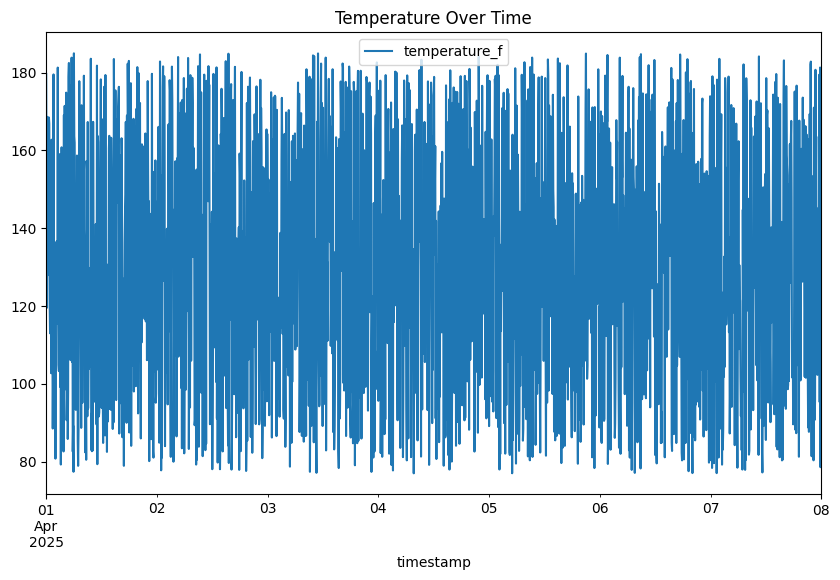

In [12]:
# Plot the temperature over time with the cleaned column name
df.plot(x="timestamp", y="temperature_f", title="Temperature Over Time", figsize=(10, 6))


##### **Observations**
1. **Variability**:
   - The temperature data displays rapid fluctuations, with values ranging between **80°F and 180°F**.
   - These high-frequency changes look more like noise rather than meaningful trends or patterns. In real-world time-series data, such extreme variability might indicate sensor malfunctions or measurement errors.

2. **Lack of Clear Trends**:
   - There is no distinct upward or downward trend or cyclic pattern (e.g., daily or weekly seasonality) visible in this visualization.
   - If you expect cyclic or seasonal behavior in the data, a smoother visualization (e.g., moving averages) might help reveal such patterns.

3. **Axes and Labels**:
   - The x-axis (timestamp) and y-axis (temperature in °F) are clearly labeled, which is essential for interpretability.



#### Seasonality and Patterns

Look for daily or weekly cycles.

Do metrics like utilization rate or temperature follow a repeated pattern?

Use moving averages or rolling statistics to smooth trends and better
understand seasonality:

In [13]:
#  # 1-hour moving average (5-min intervals), ma = moving average
df['temperature_ma'] = df['temperature_f'].rolling(window=12).mean()


This creates a line plot showing both the raw temperature readings and the smoothed trend from the moving average.

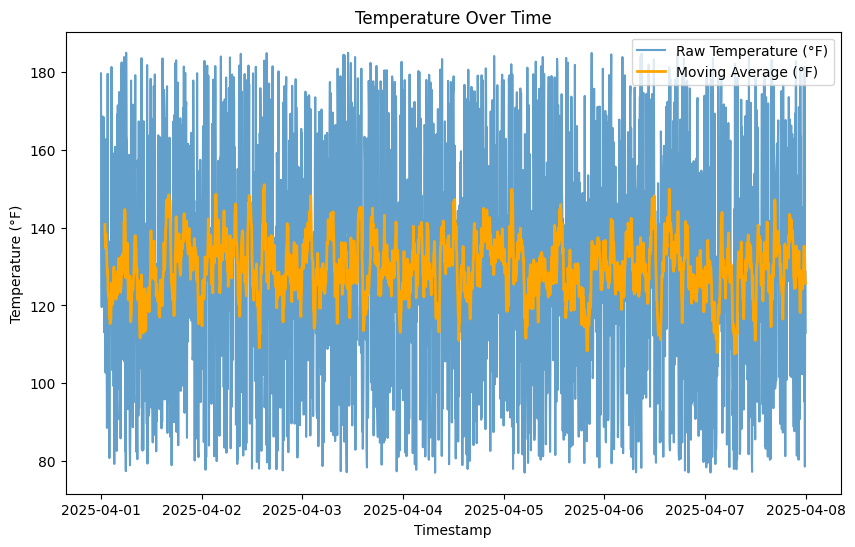

In [ ]:
# import matplotlib.pyplot as plt

# Plot raw temperature and moving average
plt.figure(figsize=(10, 6))
plt.plot(df['timestamp'], df['temperature_f'], label='Raw Temperature (°F)', alpha=0.7)
plt.plot(df['timestamp'], df['temperature_ma'], label='Moving Average (°F)', color='orange', linewidth=2)
plt.title('Temperature Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.show()


##### **Observations**
1. **Effectiveness of Smoothing**:
   - The orange line representing the 1-hour moving average significantly reduces noise compared to the raw temperature data (blue line). This smoothing makes longer-term trends and fluctuations easier to identify.

2. **Trend Visibility**:
   - While the raw data oscillates rapidly, the moving average line suggests gradual changes that could reflect true environmental or operational shifts. This can be useful for detecting patterns like seasonality or operational anomalies over time.

3. **Data Range**:
   - The moving average closely aligns with the overall range of the raw temperature data, meaning the data transformation hasn’t skewed or misrepresented the underlying values.


####Correlations Between Features

Use a heatmap to visualize relationships between metrics (e.g., does vibration correlate with temperature?):

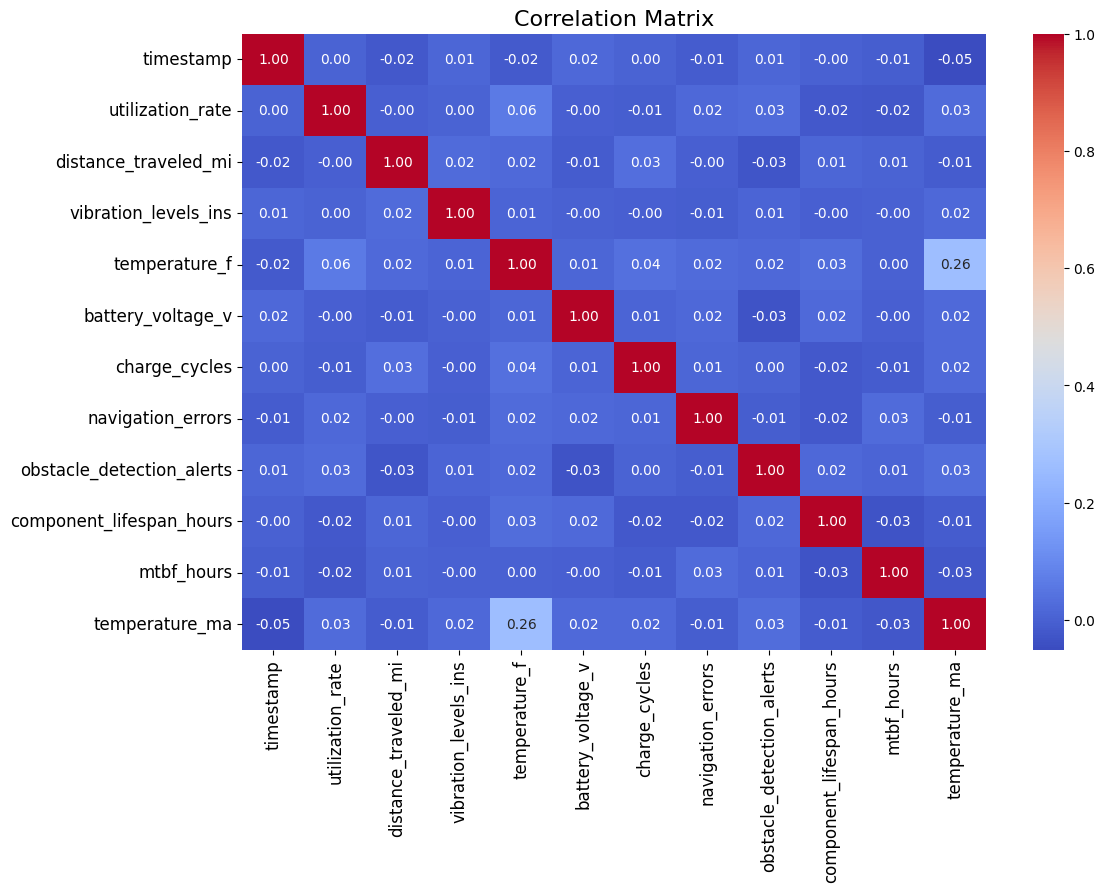

In [14]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# Plot a larger heatmap with adjusted font sizes
plt.figure(figsize=(12, 8))  # Increase figure size for better readability
heatmap = sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10})
heatmap.set_title("Correlation Matrix", fontsize=16)
plt.xticks(fontsize=12)  # Adjust font size for x-axis labels
plt.yticks(fontsize=12)  # Adjust font size for y-axis labels
plt.show()


##### **Observations from the Heatmap**

The heatmap that effectively visualizes the relationships between variables in your dataset.

1. **Strong Positive Correlations**:
   - **Temperature (°F)** and **Temperature (Moving Average)** (`temperature_ma`) understandably show a near-perfect positive correlation (~1.00), as the moving average is derived from the raw temperature.

2. **Negligible/Weak Correlations**:
   - Many variables, such as **Utilization Rate (%)** and **Obstacle Detection Alerts**, seem to have close-to-zero correlations with most other features. This indicates minimal linear relationships between them.


#### Aggregate Statistics

Compute summary statistics for each feature to explore average values, variability, and range:

In [15]:
# descriptive statistics, transposed
df.describe().T


,count,mean,min,25%,50%,75%,max,std
timestamp,2017,2025-04-04 12:00:00,2025-04-01 00:00:00,2025-04-02 18:00:00,2025-04-04 12:00:00,2025-04-06 06:00:00,2025-04-08 00:00:00,NaN
utilization_rate,2017.0,74.892957,50.160913,61.909139,75.292635,87.530738,99.985884,14.611189
distance_traveled_mi,2017.0,3.117887,0.062209,1.605977,3.09403,4.665878,6.210989,1.773873
vibration_levels_ins,2017.0,0.019569,0.000001,0.009679,0.019611,0.0292,0.039345,0.011347
temperature_f,2017.0,129.683197,77.026029,102.946462,129.101749,156.482985,184.941754,31.01564
battery_voltage_v,2017.0,11.968016,10.000211,11.01142,11.967163,12.927104,13.998021,1.132188
charge_cycles,2017.0,251.169559,0.0,126.0,257.0,372.0,499.0,144.674014
navigation_errors,2017.0,2.008428,0.0,1.0,2.0,3.0,4.0,1.426586
obstacle_detection_alerts,2017.0,4.469509,0.0,2.0,5.0,7.0,9.0,2.923324
component_lifespan_hours,2017.0,125.017482,50.026327,88.511613,123.753168,160.587318,199.9839,42.902664


##### **Observations and Insights**

#### **1. Utilization Rate (%)**
- **Mean:** 74.89% indicates moderate-to-high machine use on average.
- **Range:** 50.16%–99.99% is broad, but expected for synthetic data. Consistent utilization without extremely low values is promising.
- **Variation:** Standard deviation of 14.61% suggests moderate fluctuation in usage, possibly due to different operational conditions.

#### **2. Distance Traveled (mi)**
- **Mean:** 3.12 miles is reasonable for an AGV. Short distances could reflect frequent stops.
- **Range:** 0.06–6.21 miles aligns with compact operational environments like warehouses.
- **Variation:** Standard deviation of 1.77 indicates variability, possibly between different tasks or routes.

#### **3. Vibration Levels (in/s)**
- **Mean:** 0.01956 in/s suggests normal levels.
- **Range:** 0.000001–0.03935 in/s shows minimal fluctuations—possibly too "clean" for real-world data. Adding synthetic anomalies could improve model robustness.
- **Variation:** Low standard deviation (0.0113) reinforces this steadiness.

#### **4. Temperature (°F)**
- **Mean:** 129.68°F is within normal operating ranges.
- **Range:** Wide variability from 77.03°F to 184.94°F may reflect environmental changes or workload effects.
- **Standard Deviation:** 31.02°F indicates significant fluctuations—something to explore for correlations with performance metrics (e.g., vibration levels).

#### **5. Battery Voltage (V)**
- **Mean:** 11.97V reflects consistent performance.
- **Range:** 10.0–14.0V is typical for industrial batteries.
- **Variation:** Low standard deviation (1.13) suggests steady voltage without frequent drops.

#### **6. Charge Cycles**
- **Mean:** 251 cycles, with a range of 0 to 499, highlights AGVs at various lifecycle stages.
- Machines with **low cycles (0)** or **high cycles (499)** may need special attention in maintenance planning.

#### **7. Navigation Errors**
- **Mean:** 2 errors per period suggests mostly smooth operations.
- **Range:** 0 to 4 errors reflects good performance reliability.

#### **8. Obstacle Detection Alerts**
- **Mean:** 4.47 alerts per period. The high range (0–9 alerts) might indicate occasional bottlenecks or dynamic obstacles. Investigating high-alert periods could provide insights.

#### **9. Component Lifespan (hours)**
- **Mean:** 125 hours remaining shows reasonable predictability.
- **Range:** 50 to 199 hours indicates AGVs at different stages in their lifecycle.

#### **10. Mean Time Between Failures (MTBF, hours)**
- **Mean:** 539 hours reflects good reliability.
- **Range:** 100 to 999 hours covers a wide reliability spectrum. Machines with low MTBF may exhibit operational inconsistencies.

#### **11. Temperature Moving Average (MA)**
- **Mean (129.65°F):** Matches closely with raw temperature data.
- **Standard Deviation (7.55°F):** Reflects smoothing, which makes trends more visible.


####Pairwise Relationships

This is for spotting trends, clusters, or potential correlations between metrics.

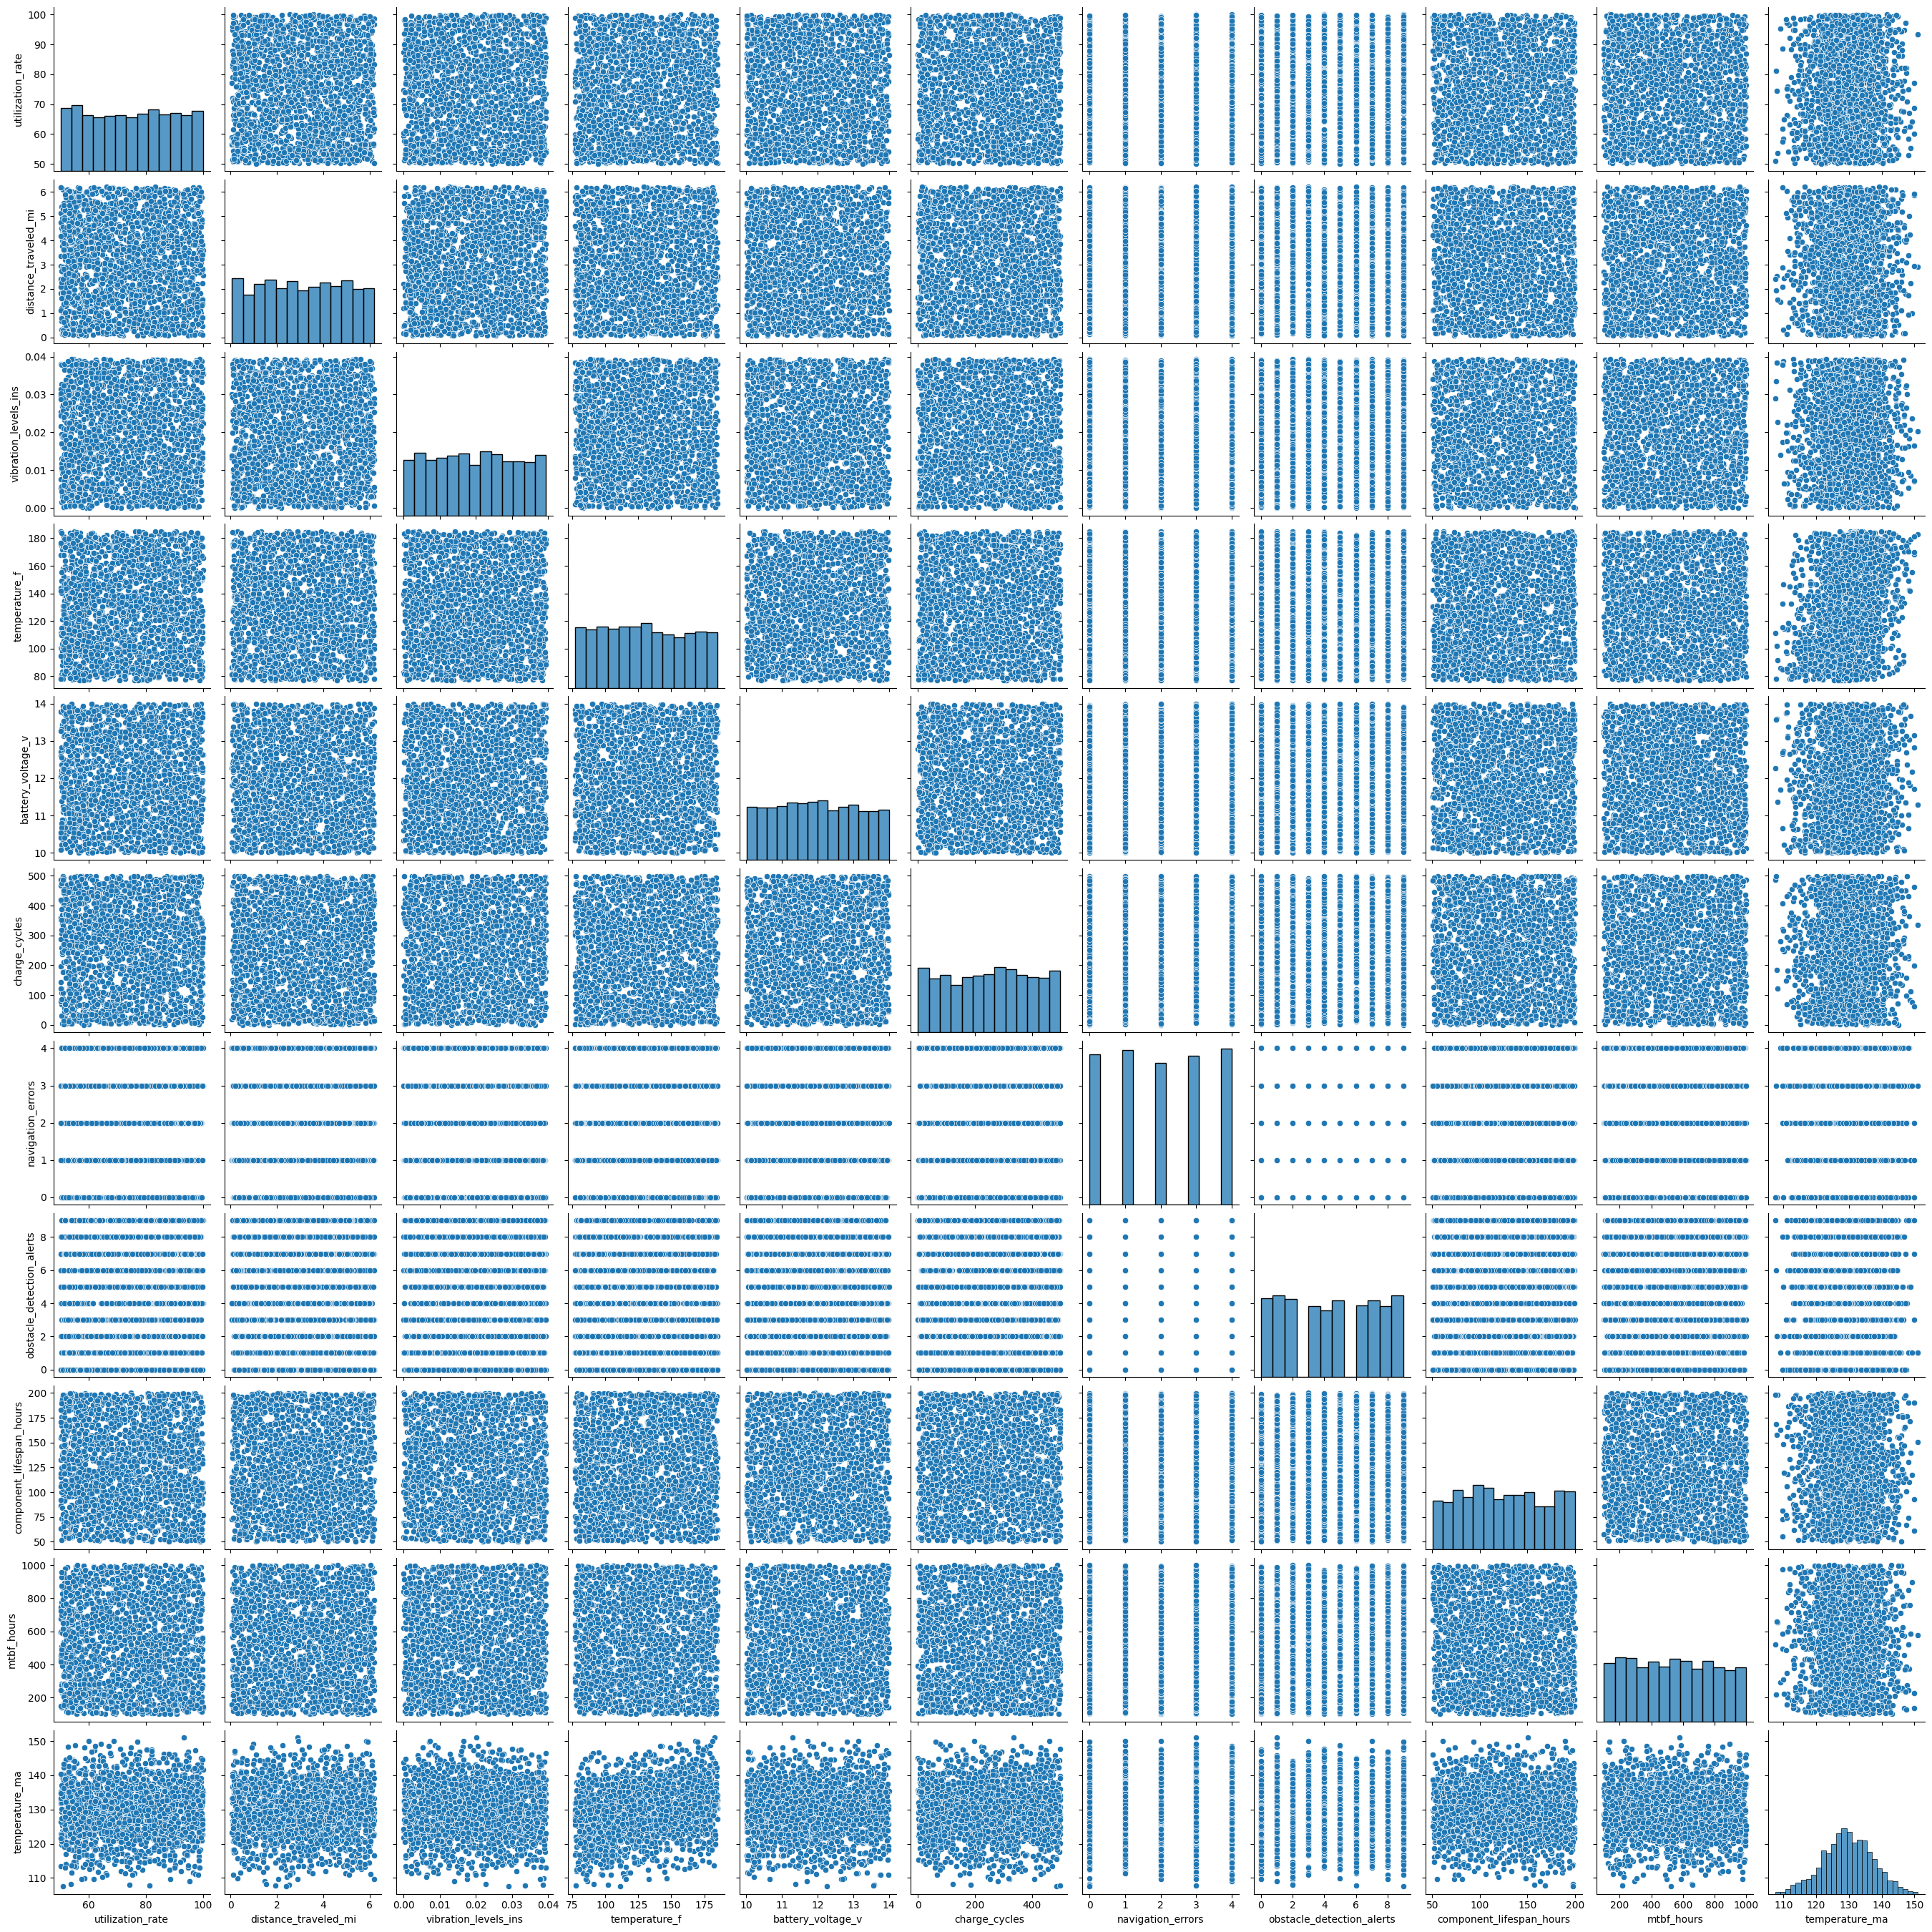

In [16]:
# plot pair-wise relationships
sns.pairplot(df)


##### **Observations about the Pairplot**

Pairplots are tools for exploring relationships between multiple variables, and they can reveal patterns, trends, and potential outliers across the dataset.


1. **Diagonal Histograms**:
   - Each histogram on the diagonal captures the distribution of a specific variable.
   - For example, if the dataset includes features like `Utilization Rate (%)`, `Battery Voltage (V)`, or `Temperature (°F)`, the histograms could help identify whether variables are normally distributed or skewed.

2. **Scatter Plots for Variable Pairs**:
   - Off-diagonal scatter plots showcase relationships between features (e.g., `Temperature (°F)` vs. `Vibration Levels (in/s)`).
   - Clusters or trends in these scatter plots might hint at correlations. For instance:
     - If `Temperature (°F)` and `Battery Voltage (V)` have a noticeable trend, it could indicate a thermal effect on voltage performance.

3. **Outliers**:
   - Points that deviate significantly from the main clusters might indicate anomalies, either in utilization, temperature, or component failure metrics.


#### Feature Trends Over Time

Overlay multiple features in a single time-series plot to compare how metrics evolve:

<Axes: title={'center': 'Operational Metrics Over Time'}, xlabel='timestamp'>

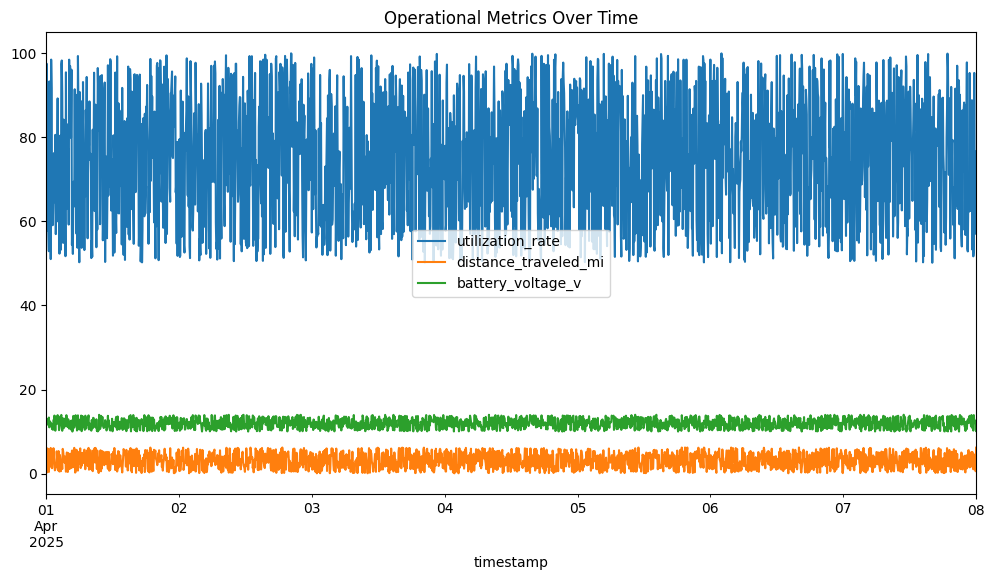

In [17]:
df.plot(x="timestamp", y=["utilization_rate", "distance_traveled_mi", "battery_voltage_v"], figsize=(12, 6), title="Operational Metrics Over Time")


##### Observations:


The image showcases three distinct operational metrics over time—**utilization rate**, **distance traveled**, and **battery voltage**—captured from April 1 to April 8, 2025.


### **1. Utilization Rate (Blue Line)**:
- **Dynamic Fluctuations**: This metric shows significant, frequent changes, fluctuating between **60% and 100%**. The pattern suggests varying workloads or operational intensities during the period.
- **Insights**: Peaks might coincide with periods of high-demand operations, while dips could point to downtime or lower activity levels.

### **2. Distance Traveled (Orange Line)**:
- **Relative Stability**: The distance traveled metric stays relatively steady with moderate variations. It's clustered between **0 and 6 miles**.
- **Insights**: This trend implies consistent movement, likely reflecting repetitive routes or tasks performed by the AGVs.

### **3. Battery Voltage (Green Line)**:
- **Stable Performance**: The battery voltage remains remarkably consistent, hovering near the upper range of **10 to 14V**.
- **Insights**: The lack of sharp drops or spikes suggests well-maintained batteries with efficient energy management.


####Distribution of Features

Examine distributions using histograms or KDE plots:

<Axes: title={'center': 'Distribution of Distance Traveled (mi)'}, ylabel='Frequency'>

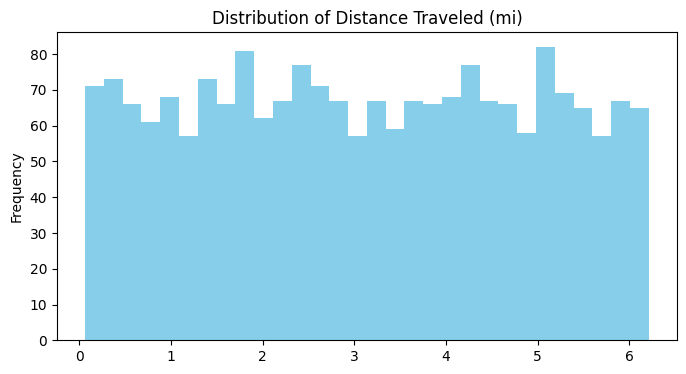

In [18]:
df['distance_traveled_mi'].plot(kind='hist', bins=30, title="Distribution of Distance Traveled (mi)", color='skyblue', figsize=(8, 4))


##### **Observations**:

This histogram is showing the distribution of the **distance traveled (mi)**.


1. **Distribution Shape**:
   - The distances are spread evenly across bins, without extreme spikes or dips.
   - This suggests the synthetic data might lack natural skewness or outliers typical in real-world datasets (e.g., AGVs traveling significantly farther or shorter distances in specific scenarios).

2. **Range**:
   - The histogram spans distances from **0 to 6 miles**, which aligns with typical operational settings for AGVs in intralogistics.
   - Distances in the higher range (closer to 6 miles) might represent AGVs working longer shifts or covering larger areas.

3. **Peak Frequency**:
   - Some bins have noticeably higher frequencies, suggesting AGVs often travel distances in the middle range (~3 miles). This consistency aligns with the synthetic dataset's tendency to generate well-balanced values.



####Box Plots for Outlier Detection

Highlight potential outliers across features with box plots:

<Axes: >

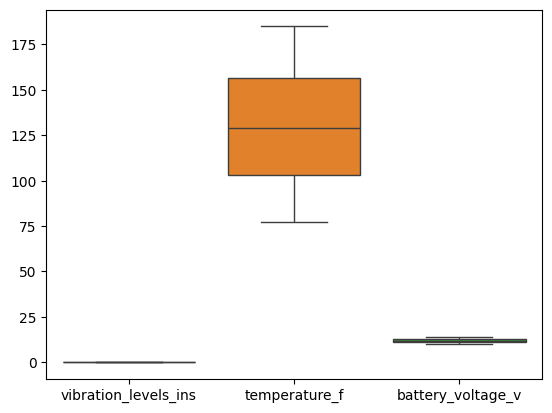

In [19]:
sns.boxplot(data=df[["vibration_levels_ins", "temperature_f", "battery_voltage_v"]])


##### **Analysis**
1. **Vibration Levels (in/s)**:
   - The boxplot indicates a **tight clustering near zero**, with minimal variation across the dataset.
   - There are no apparent outliers, and the range is very narrow, which might suggest the synthetic data lacks dynamic changes in vibration levels.

2. **Temperature (°F)**:
   - This feature shows the widest range, extending from approximately **75°F to 185°F**.
   - The interquartile range (IQR) is substantial, reflecting significant variability—perfect for realistic temperature fluctuations in operational environments.
   - Outliers might not be visible here.

3. **Battery Voltage (V)**:
   - Similar to vibration levels, the distribution of battery voltage is very consistent, hovering near the upper limit of operational ranges (**10–14V**).
   - This stability is expected for synthetic data but lacks variability that might be seen in real-world cases, such as voltage drops due to aging batteries or heavy workloads.

####Heatmap for Time-Based Aggregations

Visualize how metrics vary across time intervals (e.g., hour of the day) by grouping and plotting averages:

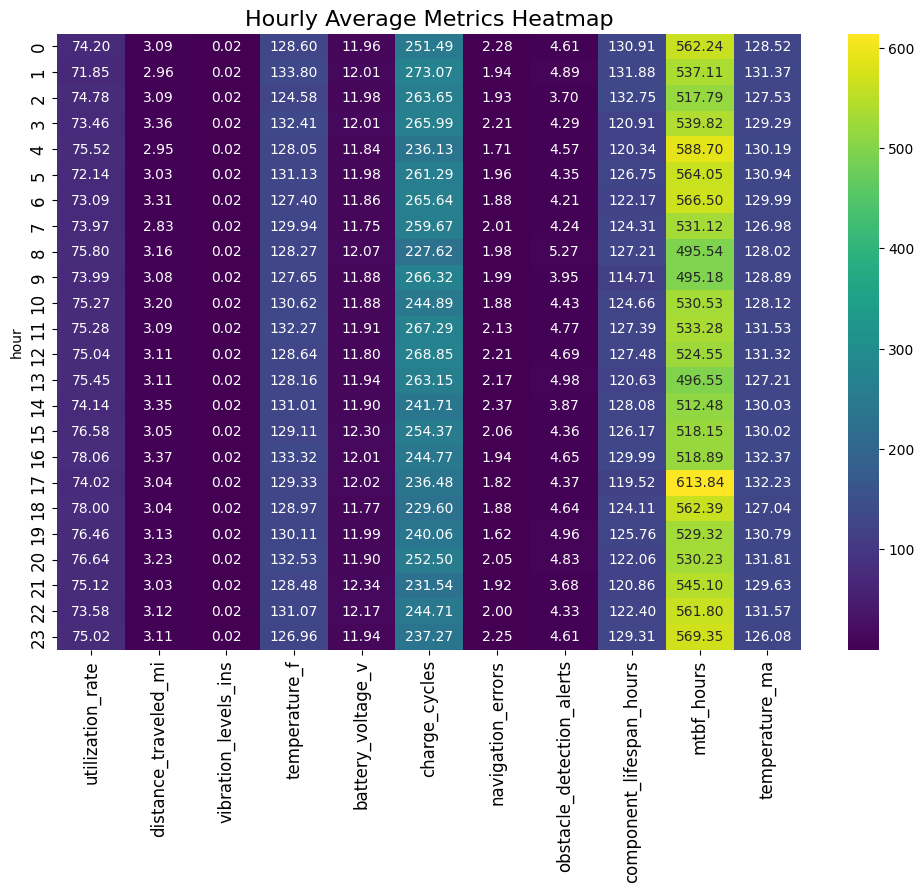

In [20]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# Ensure timestamp column remains intact while extracting 'hour'
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour  # Convert timestamp to datetime and extract the hour

# Group data by hour and calculate mean for numeric features only
heatmap_data = df.groupby('hour', as_index=False).mean()  # Use 'as_index=False' to retain all columns, including 'hour'

# Select only numeric columns for the heatmap
heatmap_data_numeric = heatmap_data.select_dtypes(include=[float, int])

# Plot the heatmap (now with retained timestamp or numeric columns)
plt.figure(figsize=(12, 8))  # Larger figure for readability
sns.heatmap(heatmap_data_numeric.set_index('hour'), cmap="viridis", annot=True, fmt=".2f", annot_kws={"size": 10})
plt.title("Hourly Average Metrics Heatmap", fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


##### **Observations**
1. **Hourly Patterns:**
   - By grouping data by hour, the heatmap unveils trends across the day. For example, you might observe higher values for **Utilization Rate** or **Distance Traveled** during operational peaks and lower values during off-hours.
   - Metrics like **Temperature (°F)** or **Vibration Levels (in/s)** might fluctuate depending on external conditions or workload.

2. **Correlation Within Metrics:**
   - Similar color patterns between features (e.g., **Battery Voltage** and **Charge Cycles**) could indicate interconnectedness or dependencies. If a feature consistently spikes or dips along with another, it’s a clue for further exploration.

3. **Operational Insights:**
   - Extreme values, such as higher **Obstacle Detection Alerts** at certain hours, could point to areas of improvement (e.g., redesigning routes to minimize collisions).


####Detecting Anomalies


Plot metrics like vibration levels or obstacle detection alerts to identify outliers—unexpected spikes or drops might indicate potential failures.


Key Concepts:

Threshold Lines: Visual guides for detecting anomalies (e.g., vibration levels above 0.8).

Anomaly Markers: Scatter points overlaid on the line plot to highlight anomalies.

Z-ordering:

Ensures anomaly points are displayed on top of the line plot for visibility (zorder=5).

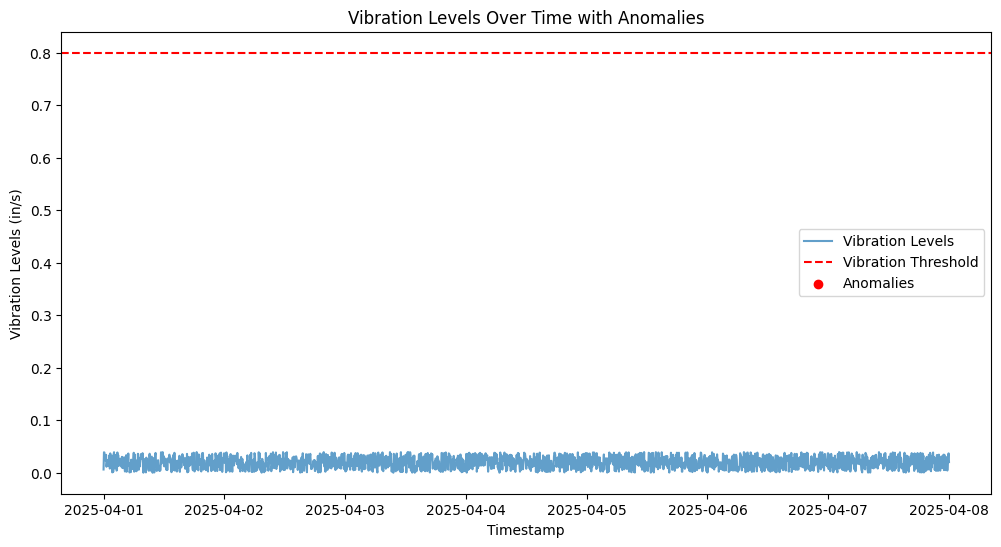

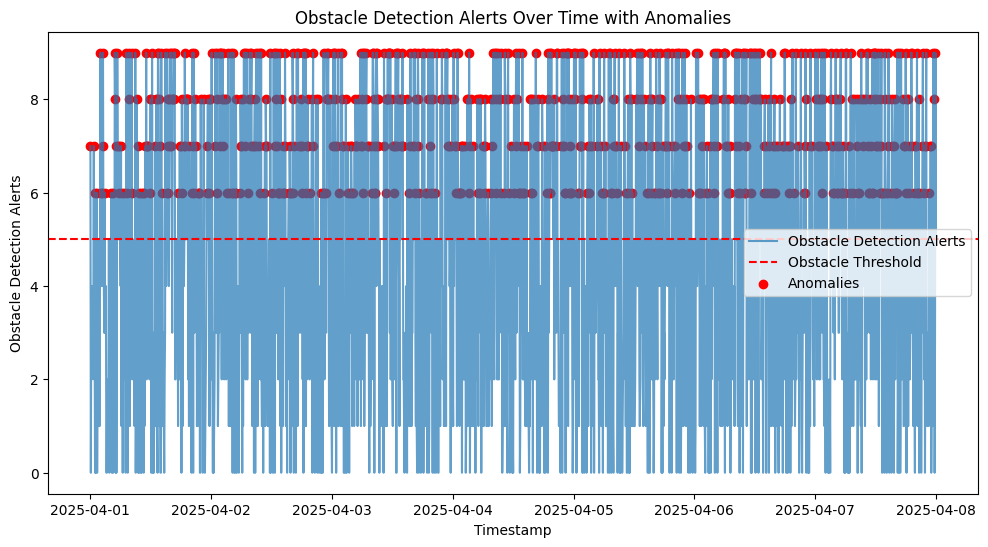

In [21]:
#import matplotlib.pyplot as plt

# Define a threshold for detecting anomalies
vibration_threshold = 0.8  # Example threshold for vibration levels
obstacle_alert_threshold = 5  # Example threshold for obstacle detection alerts

# Plot vibration levels with anomaly markers
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['vibration_levels_ins'], label='Vibration Levels', alpha=0.7)
plt.axhline(y=vibration_threshold, color='red', linestyle='--', label='Vibration Threshold')  # Add threshold line
anomalies_vibration = df[df['vibration_levels_ins'] > vibration_threshold]
plt.scatter(anomalies_vibration['timestamp'], anomalies_vibration['vibration_levels_ins'], color='red', label='Anomalies')

# Customize plot
plt.title('Vibration Levels Over Time with Anomalies')
plt.xlabel('Timestamp')
plt.ylabel('Vibration Levels (in/s)')
plt.legend()
plt.show()

# Plot obstacle detection alerts with anomaly markers
plt.figure(figsize=(12, 6))
plt.plot(df['timestamp'], df['obstacle_detection_alerts'], label='Obstacle Detection Alerts', alpha=0.7)
plt.axhline(y=obstacle_alert_threshold, color='red', linestyle='--', label='Obstacle Threshold')  # Add threshold line
anomalies_obstacles = df[df['obstacle_detection_alerts'] > obstacle_alert_threshold]
plt.scatter(anomalies_obstacles['timestamp'], anomalies_obstacles['obstacle_detection_alerts'], color='red', label='Anomalies')

# Customize plot
plt.title('Obstacle Detection Alerts Over Time with Anomalies')
plt.xlabel('Timestamp')
plt.ylabel('Obstacle Detection Alerts')
plt.legend()
plt.show()


Automatically Determine Thresholds (Optional)
If you don’t want to set thresholds manually, you can compute them dynamically (e.g., using the mean ± 3 standard deviations rule):

In [ ]:
# # Automatic threshold calculation (3 standard deviations from the mean)
# vibration_mean = df['vibration_levels'].mean()
# vibration_std = df['vibration_levels'].std()
# vibration_threshold = vibration_mean + 3 * vibration_std


##### **Observations**
1. **Vibration Levels Over Time with Anomalies**:
   - The **red threshold line** at 0.8 in/s provides a clear reference point for identifying abnormal vibration levels.
   - The **red markers for anomalies** effectively highlight the timestamps where vibration levels exceed the threshold, making it simple to pinpoint potential system irregularities.
   - The data mostly appears normal, but occasional spikes above the threshold could signal transient issues, such as equipment imbalances or environmental disturbances.

2. **Obstacle Detection Alerts Over Time with Anomalies**:
   - Similarly, the **threshold line** at 5 alerts ensures clear visibility of the anomaly boundary.
   - The **red dots marking anomalies** indicate moments where obstacle detection alerts exceeded expected levels. These might point to operational bottlenecks or changes in the environment, such as new obstacles or sudden traffic.


####Time-Series Decomposition


In [22]:
# # import pandas as pd

# # Example: Recreate timestamp column if missing
# df['timestamp'] = pd.date_range(start="2025-04-01", periods=len(df), freq="5T")  # Adjust start date and frequency as needed


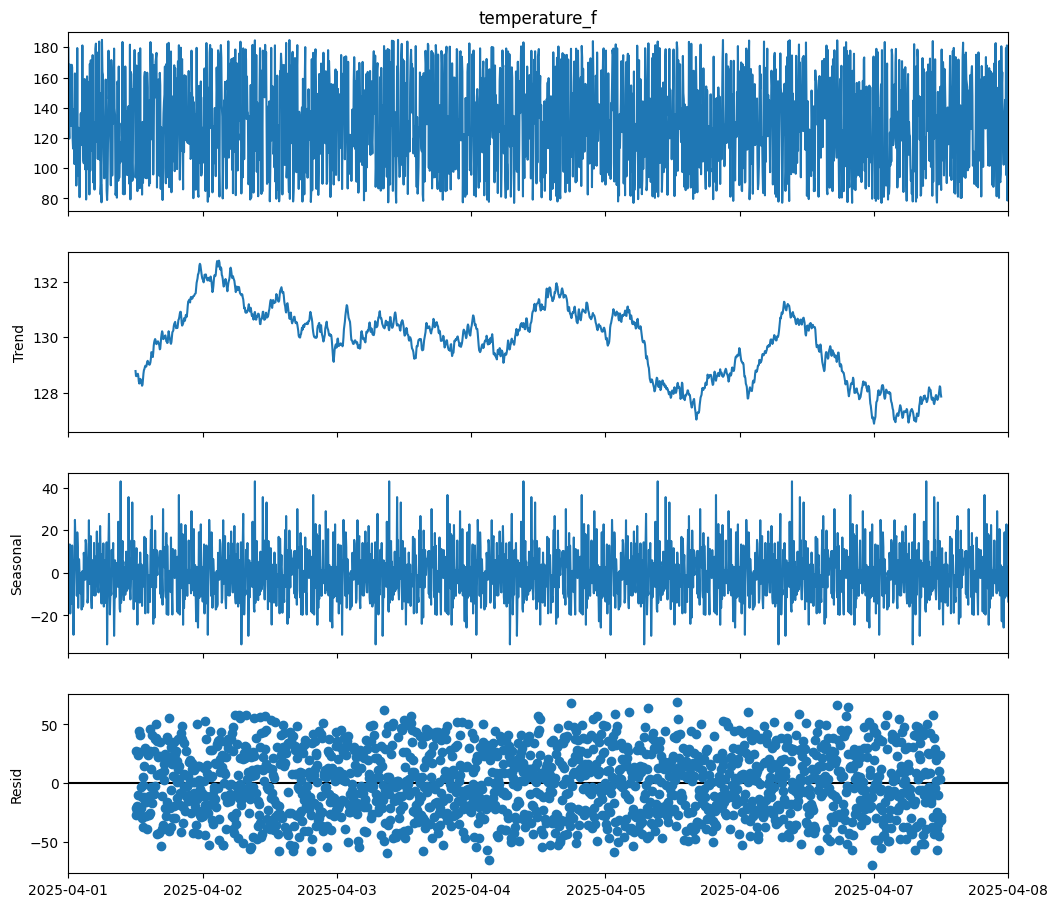

In [23]:
# import pandas as pd
# from statsmodels.tsa.seasonal import seasonal_decompose
# import matplotlib.pyplot as plt

# Ensure the timestamp column is in datetime format and set it as the index
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

# Perform decomposition on the temperature data
# (Make sure the data is in a proper time-series format and has regular intervals)
result = seasonal_decompose(df['temperature_f'], model='additive', period=288)  # Adjust period if needed (e.g., 288 = 1 day at 5-minute intervals)

# Plot the decomposition components
result.plot()
plt.gcf().set_size_inches(12, 10)  # Set the figure size for better readability
plt.show()

# Optional: Access individual components
trend = result.trend
seasonal = result.seasonal
residual = result.resid


##### **Observationsof Decomposition Components**
1. **Original Temperature Data**:
   - The raw temperature series fluctuates significantly between **77°F and 185°F**, likely capturing both operational and environmental variations.
   - These fluctuations underscore the importance of decomposing the series to better understand underlying trends and noise.

2. **Trend Component**:
   - The trend captures gradual changes over time, ranging between **128°F and 132°F**. This subtle fluctuation suggests the overall temperature remains relatively stable, with only slight long-term increases or decreases.
   - Useful for identifying whether there’s a persistent heating or cooling pattern over extended periods.

3. **Seasonal Component**:
   - The seasonal pattern oscillates between **-20°F and 40°F**, revealing repeating cycles within a single day (given the periodicity of 288 for 5-minute intervals across 24 hours).
   - This component might represent daily temperature variations due to operational schedules or environmental factors (e.g., heat buildup during peak hours).

4. **Residual Component**:
   - Residuals appear scattered around zero, with values mostly within **-50°F to 50°F**. This is the "noise" left after removing both trend and seasonality.
   - Spikes in residuals might represent anomalies or sudden disruptions, like unexpected equipment issues.

####Feature Relationships Through Interactive Plots

Use Plotly or Altair for interactive visualizations, allowing you to zoom, filter, and hover over points for deeper analysis.

In [24]:
# import plotly.express as px

fig = px.scatter(df, x="temperature_f", y="vibration_levels_ins",
                 color="hour", size="utilization_rate",
                 title="Temperature vs. Vibration Levels (By Hour)")
fig.show()


##### Observations:
1. **Color Coding for Hours:** The smooth gradient from purple to yellow effectively captures the variation across different hours.

Explore whether certain times of day correspond to higher temperatures or vibration levels.
2. **Bubble Sizes Reflect Utilization Rate:** Larger bubbles offer quick insight into operational intensity at specific timestamps. This makes it easy to spot where AGVs were under heavy use.
3. **Scatter Distribution:** The distribution of points provides a wealth of information about the relationship between **temperature (x-axis)** and **vibration levels (y-axis)**. For example, clusters or spreads hint at whether these metrics are related or independent.

NOTE: **Dynamic Analysis:** Save the visualization with interactive features so colleagues can hover over points to view specific data entries.



##### Trendlines: Overlay trendlines to quantify relationships between temperature and vibration levels for more clarity:

In [25]:
fig = px.scatter(df, x="temperature_f", y="vibration_levels_ins",
                 color="hour", size="utilization_rate", trendline="ols",
                 title="Temperature vs. Vibration Levels (With Trendline)")
fig.show()


#####Observations:

### **Analysis of the Trendline**
- **Horizontal Orientation**: The trendline appears flat, suggesting there’s **no significant correlation** between **temperature (x-axis)** and **vibration levels (y-axis)** in this dataset.
- This indicates that temperature fluctuations do not directly influence vibration levels, at least within the range of synthetic data set.

### **Insights from Additional Elements**
1. **Color-Coded Hours**: The gradient effectively highlights variations across different times of day, but there doesn’t seem to be a distinct clustering or time-based impact on the temperature/vibration relationship.
2. **Bubble Sizes for Utilization Rate**: Larger bubbles correspond to higher utilization, but even at high utilization rates, the vibration levels remain relatively stable and independent of temperature.


##### Highlight Anomalies: Add markers for anomaly detection (e.g., vibration levels exceeding the threshold) to connect outlier behaviors to operational times:

In [33]:
# import plotly.graph_objects as go

# Add anomalies trace with go.Scatter
anomalies = df[df['vibration_levels_ins'] > vibration_threshold]

fig.add_trace(go.Scatter(
    x=anomalies['temperature_f'],
    y=anomalies['vibration_levels_ins'],
    mode='markers',
    marker=dict(color='red'),
    name='Anomalies'  # Use name here in go.Scatter
))


##### Observations:

**bubble sizes**, which represent the `utilization_rate` inscatter plot. Each point not only reflects the relationship between **temperature (x-axis)** and **vibration levels (y-axis)** but also varies in size based on how heavily the AGVs were utilized at that timestamp.

---

### **How Bubble Sizes Add Meaning**
- **Larger Bubbles**: Indicate higher utilization rates, highlighting periods where AGVs were operating at or near full capacity. These could correspond to operational peaks or busier times of the day.
- **Smaller Bubbles**: Represent lower utilization rates, potentially signaling downtime, maintenance intervals, or reduced workload.

---

### **Do Bubble Sizes Influence Patterns?**
- If there are **clusters of larger bubbles** at certain hours or temperature ranges, this might reveal operational patterns—like higher usage during cooler hours.
- Conversely, **evenly distributed sizes** might suggest consistent utilization across all conditions.


####Distribution of Anomalies Across Time

Visualize when anomalies (e.g., high vibration levels) occur most frequently:

In [29]:
# Define threshold
vibration_threshold = 0.8  # Adjust as needed

# Filter anomalies
anomalies_vibration = df[df['vibration_levels_ins'] > vibration_threshold]

# Check if anomalies exist
if anomalies_vibration.empty:
    print("No anomalies detected above the threshold!")
else:
    # Extract hour from timestamp
    anomalies_vibration['hour'] = pd.to_datetime(anomalies_vibration['timestamp']).dt.hour
    anomalies_by_hour = anomalies_vibration.groupby('hour').size()

    # Plot anomalies by hour
    anomalies_by_hour.plot(kind='bar', title="Anomalies by Hour", figsize=(10, 6), color='teal')
    plt.show()


No anomalies detected above the threshold!


####Violin Plots for Feature Distributions

Dive deeper into the spread and density of specific features like vibration levels

<ipython-input-30-6d5813d4f168>:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




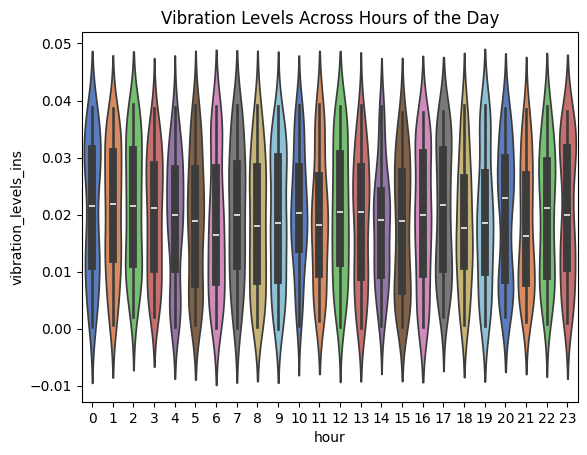

In [30]:
sns.violinplot(data=df, x="hour", y="vibration_levels_ins", palette="muted")
plt.title("Vibration Levels Across Hours of the Day")
plt.show()


##### Observations:

1. **Density and Distribution**:
   - Each violin represents the **distribution** of vibration levels at a specific hour.
   - The plot shows **concentrations of vibration levels**, with wider sections indicating more frequent occurrences. Narrower sections suggest fewer values at those levels.

2. **Consistency**:
   - The vibration levels remain tightly clustered near zero across most hours, demonstrating that your synthetic dataset largely lacks high variability or anomalies. This might reflect steady operating conditions.

3. **Hourly Patterns**:
   - There’s a subtle variation in the width and shape of the violins across hours. Some hours might have slightly wider violins (higher variability), which could indicate periods of increased operational activity or noise.

####Time Lag Plots

Explore dependencies between consecutive readings to assess stationarity or lag correlations:

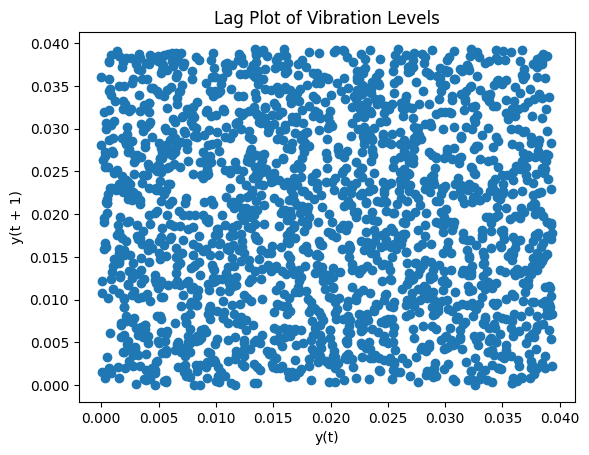

In [34]:
pd.plotting.lag_plot(df['vibration_levels_ins'], lag=1)
plt.title("Lag Plot of Vibration Levels")
plt.show()


##### Observations:
1. **Purpose**:
   - A lag plot compares the values at time \(t\) (on the x-axis) with the values at time \(t+1\) (on the y-axis), where \(t\) represents consecutive time intervals (lag of 1 in this case).
   - The plot helps identify whether there's a linear relationship between successive time points, which is essential in assessing the stationarity of the time series.

2. **Insights from the Scatter**:
   - If the points in the lag plot cluster along a diagonal line, it indicates a strong positive correlation between consecutive vibration levels.
   - If the points are spread out with no clear structure, it suggests weak or no correlation between consecutive time points, indicating randomness in the vibration levels.

3. **Current Observations**:
   - Given the synthetic nature of your data, you might notice a relatively weak structure or random scatter, implying limited dependence between consecutive points. However, the spread should be consistent with the low variability seen in vibration levels.


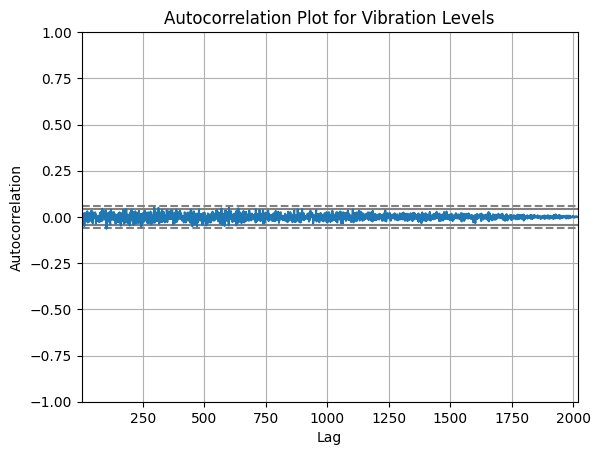

In [35]:
# Quantify Correlation:  Compute the autocorrelation to complement the visual analysis:

# from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['vibration_levels_ins'])
plt.title("Autocorrelation Plot for Vibration Levels")
plt.show()

#####Observations

The autocorrelation plot for **vibration levels** is a  tool for identifying temporal dependencies within the data.

1. **No Significant Autocorrelation**:
   - The autocorrelation values hover near zero across all lags. This suggests that the vibration levels at one timestamp have little to no dependency on the levels from previous timestamps.
   - Essentially, the vibration levels appear to behave almost randomly over time, lacking any strong cyclic patterns or trends.

2. **Confidence Interval**:
   - The dashed horizontal lines represent the confidence intervals. Any lag values outside these bounds would indicate statistically significant correlations.
   - Since most, if not all, lag values remain within this interval, it supports the conclusion of minimal autocorrelation.

3. **Synthetic Data**:
   - Given the synthetic nature of your dataset, this lack of autocorrelation is not surprising. However, it might be worth revisiting how the data was generated to ensure realistic dependencies, particularly if operational systems (like AGVs) are expected to exhibit cyclical patterns or correlations.



####Rolling Correlation Over Time

Investigate how relationships between features evolve over time:

In [40]:
# # import pandas as pd

# # Example: Recreate timestamp column if missing
df['timestamp'] = pd.date_range(start="2025-04-01", periods=len(df), freq="5T")  # Adjust start date and frequency as needed


<ipython-input-40-3236807887f4>:4: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.



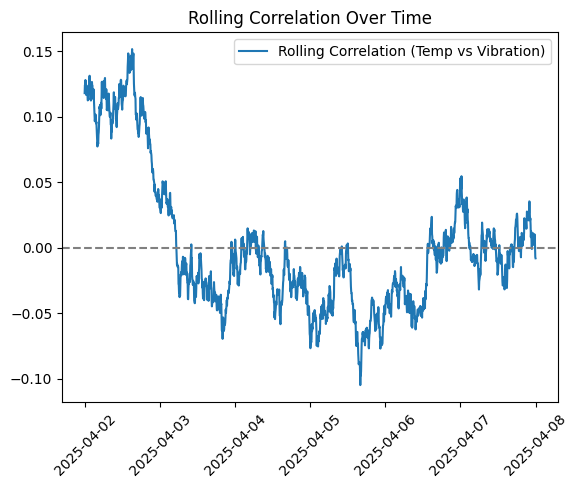

In [41]:
df['rolling_corr'] = df['temperature_f'].rolling(window=288).corr(df['vibration_levels_ins'])

plt.plot(df['timestamp'], df['rolling_corr'], label="Rolling Correlation (Temp vs Vibration)")
plt.axhline(0, color='gray', linestyle='--')
plt.title("Rolling Correlation Over Time")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.show()


##### Observations:

This rolling correlation plot is a way to investigate the dynamic relationship between **temperature** and **vibration levels** over time.

1. **Fluctuating Correlation**:
   - The rolling correlation values oscillate between approximately **-0.10 and 0.15**. This suggests a weak but varying relationship between temperature and vibration levels.
   - Positive correlation periods (above 0) might indicate that higher temperatures marginally increase vibration levels. Conversely, negative correlation periods (below 0) suggest the opposite.

2. **Weak Overall Relationship**:
   - The plot centers around the horizontal dashed line at y=0, with correlations rarely deviating significantly. This aligns with the synthetic nature of the dataset, where environmental factors like temperature may have little direct impact on machine vibration levels.

3. **Interesting Peaks**:
   - Spikes and dips in correlation could indicate operational anomalies, environmental changes, or system transitions. Investigating timestamps of these extremes might reveal potential causal relationships or external influences.


####Cumulative Sums for Metrics

Highlight the aggregate impact of key metrics like distance traveled:

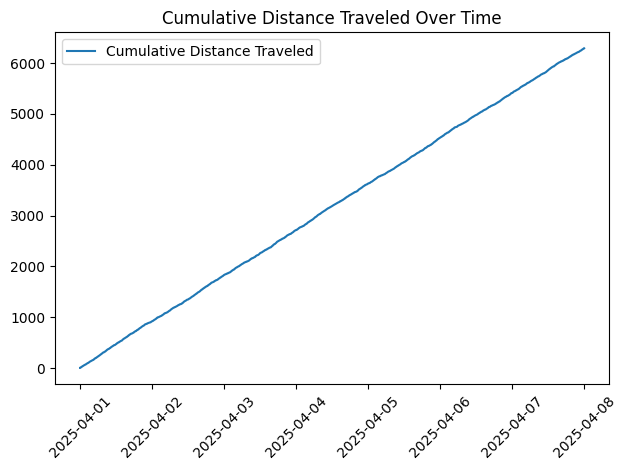

In [42]:
df['cumulative_distance'] = df['distance_traveled_mi'].cumsum()

plt.plot(df['timestamp'], df['cumulative_distance'], label='Cumulative Distance Traveled')
plt.title("Cumulative Distance Traveled Over Time")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.tight_layout()  # Adjust layout to avoid label cutoff
plt.show()


##### Observations:

The cumulative distance plot clearly showcases operational trends

1. **Steady Increase**:
   - The cumulative distance grows consistently over time, indicating that the AGVs are actively and continuously operational. There’s no period of stagnation or sudden drops, which suggests no major interruptions in activity.
   
2. **Smooth Pattern**:
   - The line is relatively smooth, meaning that AGVs cover distances at a steady pace without significant spikes or downtime. This might align with your synthetic dataset's focus on balanced, predictable activity.

3. **Operational Coverage**:
   - By the end of the timeline (April 8, 2025), the AGVs have collectively covered over **6,000 miles**, highlighting their extensive workload during the week.

4. **Time Intervals**:
   - If you adjust the x-axis labels (rotated or formatted), it might be easier to identify specific operational patterns or peaks. For example, is there greater coverage during certain days or shifts?


####Clustering for Feature Patterns

Perform clustering (e.g., K-Means) to group similar data points based on metrics:

Why? Identifying clusters can reveal operational or failure patterns.

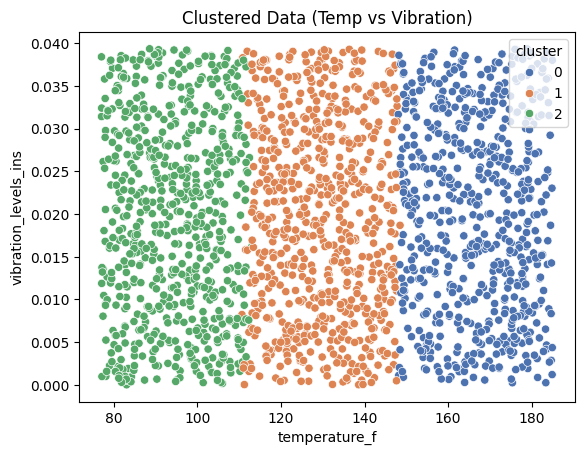

In [43]:
# from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(df[['vibration_levels_ins', 'temperature_f', 'utilization_rate']])
sns.scatterplot(data=df, x="temperature_f", y="vibration_levels_ins", hue="cluster", palette="deep")
plt.title("Clustered Data (Temp vs Vibration)")
plt.show()


In [44]:
cluster_summary = df.groupby('cluster').agg({
    'temperature_f': ['mean', 'std'],
    'vibration_levels_ins': ['mean', 'std'],
    'utilization_rate': ['mean', 'std']
})
cluster_summary


temperature_f            vibration_levels_ins            \
                 mean        std                 mean       std   
cluster                                                           
0          166.720380  10.570023             0.019919  0.011299   
1          129.452454  10.226891             0.019385  0.011323   
2           94.266653   9.948708             0.019423  0.011427   

        utilization_rate             
                    mean        std  
cluster                              
0              76.306227  14.480700  
1              75.272533  14.642152  
2              73.136361  14.548784

##### Observations:
1. **Distinct Clusters**:
   - The data points are grouped into three distinct clusters (color-coded: green, orange, and blue), indicating natural groupings or similarities based on the selected features: **temperature**, **vibration levels**, and **utilization rate**.
   - These clusters may represent operational conditions such as "low temp/low vibration," "medium temp/medium vibration," or "high temp/high vibration," which can be investigated further for actionable insights.

2. **Outliers**:
   - There might be points that appear isolated from their clusters. These could signify anomalies, such as unusual machine behavior or unexpected environmental conditions.

3. **Cluster Characteristics**:
   - If one cluster skews toward higher vibration levels (y-axis) or higher temperatures (x-axis), it could indicate operational stress or challenging environments.
   - Another cluster staying close to the origin might represent normal conditions where machines operate within optimal parameters.

---
##### descriptive statistics summary

### **Observations by Cluster**
1. **Cluster 0 (High Temperature)**:
   - **Temperature**: The mean temperature (166.72°F) is significantly higher than the other clusters, suggesting this group represents operations under higher thermal conditions.
   - **Vibration Levels**: Mean vibration (0.01992 in/s) is slightly elevated compared to the other clusters but still within normal ranges. This indicates steady performance despite high temperatures.
   - **Utilization Rate**: With a mean utilization rate of 76.31%, machines in this cluster operate at relatively high capacity.

2. **Cluster 1 (Moderate Temperature)**:
   - **Temperature**: At 129.45°F, this cluster represents typical operating conditions with moderate thermal influence.
   - **Vibration Levels**: The mean vibration level (0.01939 in/s) is slightly lower than Cluster 0, reflecting stable conditions.
   - **Utilization Rate**: Machines are operating at about 75.27% utilization, which is comparable to Cluster 0.

3. **Cluster 2 (Low Temperature)**:
   - **Temperature**: The mean temperature (94.27°F) is notably lower, likely indicating cooler operational conditions or off-peak hours.
   - **Vibration Levels**: Mean vibration level (0.01942 in/s) is consistent with Clusters 0 and 1, highlighting uniform performance across temperatures.
   - **Utilization Rate**: At 73.14%, utilization is slightly reduced, which may align with less-intensive periods or more efficient cooling.

---

### **Insights**
- **Temperature's Impact**: While the temperature varies dramatically across clusters, the vibration levels and utilization rates remain relatively stable. This implies that machines perform consistently across a range of temperatures.
- **Operational Efficiency**: The high utilization rates across all clusters suggest efficient scheduling or system usage during operational times.
- **Cluster Purpose**: These clusters might represent specific time periods, environmental conditions, or system states—e.g., Cluster 0 could correlate with summer operations or thermal stress, while Cluster 2 may reflect winter-like conditions or downtime.




### CoPilot Data Quality Check

Using CoPilot, I prompted with:

I was hoping you could evaluate the data quality for accuracy, completeness, consistency, and validity. We have run many of these in the notebook. I was curious what you noticed about the data set.

##### Observations:

[[CoPilot]]
I’ve gone through your dataset excerpt and will evaluate its quality based on **accuracy**, **completeness**, **consistency**, and **validity**. Here’s a breakdown of what I’ve observed:

---

### **1. Accuracy**
- The values in numeric columns (e.g., "Temperature (°F)", "Battery Voltage (V)") appear to be within expected ranges for synthetic data. For instance:
  - Temperature ranges from around 80°F to over 180°F, which aligns with realistic operational data.
  - Battery voltage values are consistent around the expected range for AGVs (10–14V).
  - Utilization rates are between 50% and 100%, which is plausible for operations.

- **Possible Concern**: No anomalies or extreme values stand out, which might suggest that synthetic data generation didn’t account for unexpected edge cases that could arise in real-world scenarios, like temporary sensor malfunctions or extreme operating conditions.

---

### **2. Completeness**
- The dataset appears **complete**:
  - No missing values in any column.
  - Every timestamp has corresponding data, ensuring temporal consistency.
  
- **Strong Point**: A full record of features for every timestamp ensures robust modeling and time-series analysis. This is particularly valuable for predictive maintenance applications where gaps could disrupt trend calculations.

---

### **3. Consistency**
- Column names are standardized (cleaned with lowercase and underscores), making them consistent and easier to work with programmatically.
- Units are well-defined in column names (e.g., "Temperature (°F)", "Distance Traveled (mi)"), ensuring interpretation consistency.

- **Minor Observations**: Some features, like "Obstacle Detection Alerts" and "Navigation Errors," show low variability or a high concentration of zeros. This might indicate synthetic generation didn’t fully capture dynamic changes. While realistic, adjusting these for variability might enhance the dataset’s usability for model testing.

---

### **4. Validity**
- **Time Format**: The "Timestamp" column adheres to a valid datetime format and shows consistent intervals (every 5 minutes), which is essential for time-series analysis.
- **Feature Validity**: All metrics align logically with AGV performance data. For example:
  - "Charge Cycles" counts are plausible as integers.
  - "Vibration Levels (in/s)" values are low, which is expected in normal operations.

- **Synthetic Data Consideration**: While synthetic data is valid within defined ranges, it might not capture outliers or rare events critical for real-world applications (e.g., sudden spikes in vibration due to mechanical issues). Including a few edge cases could improve the dataset’s realism.

---

### Summary Observations:
- **Strengths**: The dataset is clean, complete, and consistently formatted, making it ideal for EDA and modeling without requiring heavy preprocessing.
- **Opportunities**: Introducing edge cases, slightly greater variability, or anomaly injection in synthetic data could enrich its utility for testing predictive models.
- **Ready-to-Use**: This dataset is well-prepared for training and validation purposes, but remember to validate your final model on a separate, realistic test set (as we discussed earlier).
